<a href="https://colab.research.google.com/github/feliperib286/5-semestre-fatec/blob/main/Exerc%C3%ADcio%20Aprendizado%20Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando o dataset MNIST (isso pode levar cerca de um minuto)...
Treinando Random Forest...
--> Acurácia Random Forest: 0.9674

Treinando Extra Trees...
--> Acurácia Extra Trees: 0.9682

Treinando SVM Linear...
--> Acurácia SVM Linear: 0.9118

Treinando Ensemble...
--> Acurácia Ensemble: 0.9659

Gerando a Matriz de Confusão para o Ensemble...


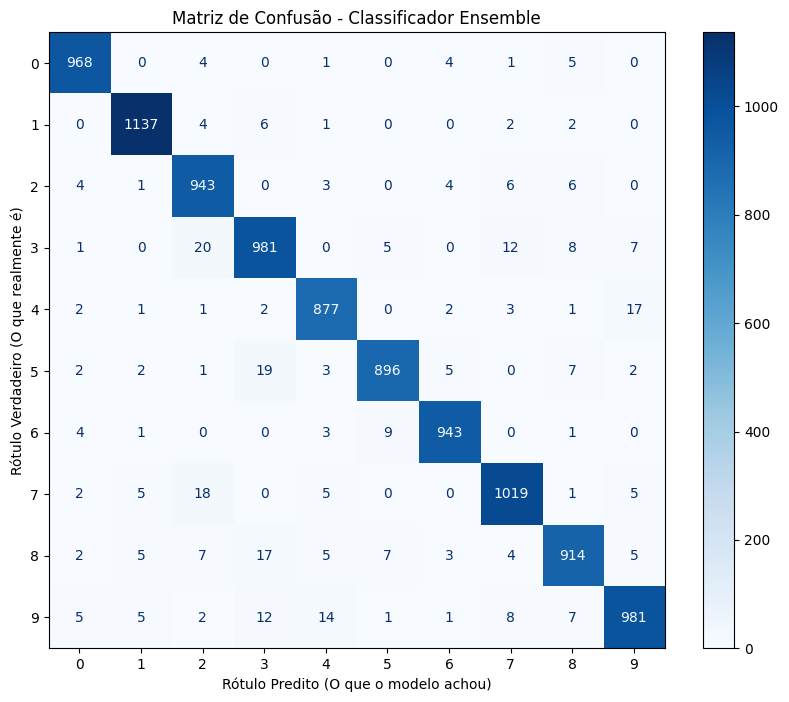

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Passo 1: Baixar dados e separar em treino e teste
print("Baixando o dataset MNIST (isso pode levar cerca de um minuto)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=10000, random_state=42)

# Passo 2: Instanciar os três classificadores isolados
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_et = ExtraTreesClassifier(n_estimators=100, random_state=42)
clf_svm = LinearSVC(dual=False, random_state=42) # dual=False otimiza o tempo no MNIST

# Passo 3: Criar o Ensemble agregando os três modelos
clf_ensemble = VotingClassifier(
    estimators=[('rf', clf_rf), ('et', clf_et), ('svm', clf_svm)],
    voting='hard'
)

# Passo 4: Treinar e comparar as acurácias
modelos = [clf_rf, clf_et, clf_svm, clf_ensemble]
nomes = ["Random Forest", "Extra Trees", "SVM Linear", "Ensemble"]

for modelo, nome in zip(modelos, nomes):
    print(f"Treinando {nome}...")
    modelo.fit(X_treino, y_treino) # Executa o treinamento
    predicoes = modelo.predict(X_teste) # Testa com os dados inéditos
    acuracia = accuracy_score(y_teste, predicoes) # Calcula porcentagem de acerto
    print(f"--> Acurácia {nome}: {acuracia:.4f}\n")
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Gerando a Matriz de Confusão para o Ensemble...")

# 1. Calcular a matriz de confusão cruzando o gabarito (y_teste) com as predições do Ensemble
matriz = confusion_matrix(y_teste, predicoes)

# 2. Configurar o visual do gráfico
fig, ax = plt.subplots(figsize=(10, 8))
grafico = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=[str(i) for i in range(10)] # Rótulos de 0 a 9
)

# 3. Plotar o gráfico com um mapa de cores azul e valores inteiros ('d')
grafico.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Matriz de Confusão - Classificador Ensemble')
plt.xlabel('Rótulo Predito (O que o modelo achou)')
plt.ylabel('Rótulo Verdadeiro (O que realmente é)')

# 4. Exibir a imagem
plt.show()